# Geometry, conditioning, and ensembles: changing the shape of the problem

Sampling difficulty is often geometric rather than mysterious. Whitening changes
coordinates, stochastic Newton proposals use local curvature, and ensemble methods infer
useful directions from a population of walkers. These mechanisms solve different
problems and fail in different ways.

**Output semantics.** Affine maps and Gaussian conditioning are exact transformations.
Metropolized stochastic Newton, stretch, and walk moves are exact-invariant Markov
kernels. Hessian repair changes proposal geometry but not the corrected target law.


In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab import spawn_rngs
from sampler_lab.ensemble import (
    EnsembleState,
    StretchMoveKernel,
    WalkMoveKernel,
    ensemble_effective_sample_size,
    mean_cross_walker_correlation,
    run_ensemble_chain,
)
from sampler_lab.experiments import (
    run_conditioning_geometry_experiment,
    run_rosenbrock_geometry_experiment,
)
from sampler_lab.geometry import (
    gaussian_conditional,
    gaussian_whitening_map,
    matrix_condition_number,
    negative_log_hessian,
)
from sampler_lab.models import GaussianTarget, RosenbrockTarget

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Whitening turns anisotropy into a coordinate choice

If $C=LL^\mathsf{T}$, the map $y=L^{-1}(x-\mu)$ sends
$N(\mu,C)$ to a standard normal. This does not approximate the target; it represents the
same probability law in better-conditioned coordinates.


In [2]:
gaussian = GaussianTarget([1.0, -2.0], [[100.0, 8.0], [8.0, 1.0]])
whitening = gaussian_whitening_map(gaussian)
whitening_rng = spawn_rngs(SEED + 10, 1)[0]
original_samples = gaussian.sample(whitening_rng, 2000 if QUICK_MODE else 8000)
whitened_samples = whitening.forward(original_samples)
original_condition = matrix_condition_number(gaussian.covariance_matrix)
whitened_covariance = np.cov(whitened_samples.T)
whitened_condition = matrix_condition_number(whitened_covariance)
print("original covariance condition number:", original_condition)
print("empirical whitened condition number:", whitened_condition)
print("empirical whitened covariance:\n", np.round(whitened_covariance, 3))

original covariance condition number: 281.35755691476766
empirical whitened condition number: 1.020487176546986
empirical whitened covariance:
 [[0.98 0.  ]
 [0.   1.  ]]


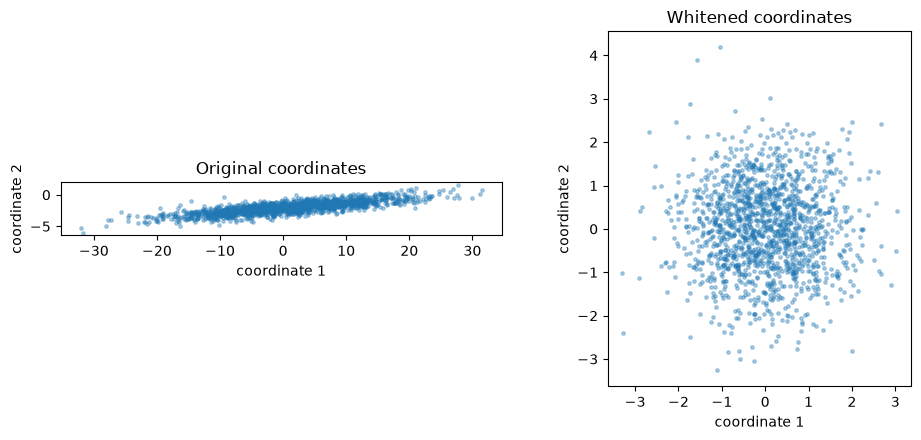

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.5))
display_count = min(1500, original_samples.shape[0])
axes[0].scatter(
    original_samples[:display_count, 0],
    original_samples[:display_count, 1],
    s=6,
    alpha=0.35,
)
axes[1].scatter(
    whitened_samples[:display_count, 0],
    whitened_samples[:display_count, 1],
    s=6,
    alpha=0.35,
)
axes[0].set_title("Original coordinates")
axes[1].set_title("Whitened coordinates")
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("coordinate 1")
    ax.set_ylabel("coordinate 2")
finish_figure(fig)

## 2. Exact Gaussian conditioning

Conditioning is another geometric operation. The Schur-complement formula produces the
exact remaining Gaussian law, including the covariance reduction caused by observing a
correlated coordinate.


In [4]:
conditional_base = GaussianTarget(
    [0.0, 1.0, -1.0],
    [[2.0, 1.1, 0.4], [1.1, 1.5, -0.2], [0.4, -0.2, 1.0]],
)
conditional = gaussian_conditional(
    conditional_base,
    observed_indices=[1],
    observed_values=[2.5],
)
print("remaining coordinates:", conditional.remaining_indices)
print("conditional mean:", np.round(conditional.target.mean_vector, 4))
print("conditional covariance:\n", np.round(conditional.target.covariance_matrix, 4))

remaining coordinates: [0 2]
conditional mean: [ 1.1 -1.2]
conditional covariance:
 [[1.1933 0.5467]
 [0.5467 0.9733]]


## 3. Local curvature can be indefinite

Stochastic Newton uses the negative log-density Hessian as a local precision. On a
non-log-concave target such as Rosenbrock, that matrix can be indefinite away from the
valley. Repair must be explicit: clipping and absolute-value repair imply different
local proposals.


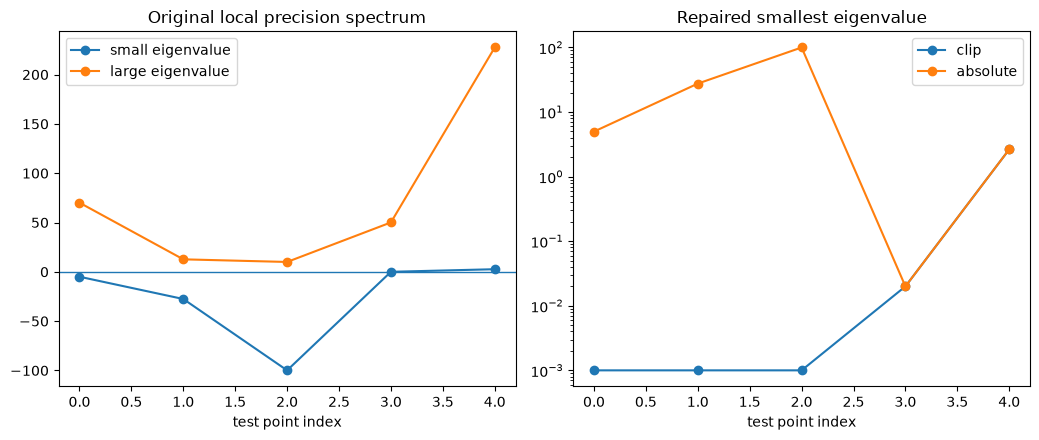

In [5]:
rosenbrock = RosenbrockTarget()
hessian_points = np.array([[-1.5, 4.0], [-0.5, 2.0], [0.0, 5.0], [1.0, 1.0], [2.0, 1.0]])
original_eigenvalues = []
clipped_eigenvalues = []
absolute_eigenvalues = []
for point in hessian_points:
    clipped = negative_log_hessian(
        rosenbrock,
        point,
        repair_method="clip",
        minimum_eigenvalue=1e-3,
    )
    absolute = negative_log_hessian(
        rosenbrock,
        point,
        repair_method="absolute",
        minimum_eigenvalue=1e-3,
    )
    original_eigenvalues.append(clipped.original_eigenvalues)
    clipped_eigenvalues.append(clipped.repaired_eigenvalues)
    absolute_eigenvalues.append(absolute.repaired_eigenvalues)
original_eigenvalues = np.asarray(original_eigenvalues)
clipped_eigenvalues = np.asarray(clipped_eigenvalues)
absolute_eigenvalues = np.asarray(absolute_eigenvalues)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
axes[0].plot(original_eigenvalues[:, 0], "o-", label="small eigenvalue")
axes[0].plot(original_eigenvalues[:, 1], "o-", label="large eigenvalue")
axes[0].axhline(0.0, linewidth=1.0)
axes[0].set_title("Original local precision spectrum")
axes[1].plot(clipped_eigenvalues[:, 0], "o-", label="clip")
axes[1].plot(absolute_eigenvalues[:, 0], "o-", label="absolute")
axes[1].set_yscale("log")
axes[1].set_title("Repaired smallest eigenvalue")
for ax in axes:
    ax.set_xlabel("test point index")
    ax.legend()
finish_figure(fig)

## 4. CLI-matched conditioned-Gaussian experiment

Isotropic random-walk Metropolis pays for the longest and shortest target scales at once.
A covariance-aware proposal and stochastic Newton adapt the move geometry. The same
target family and seed are used by `sampler-lab-geometry-demo`.


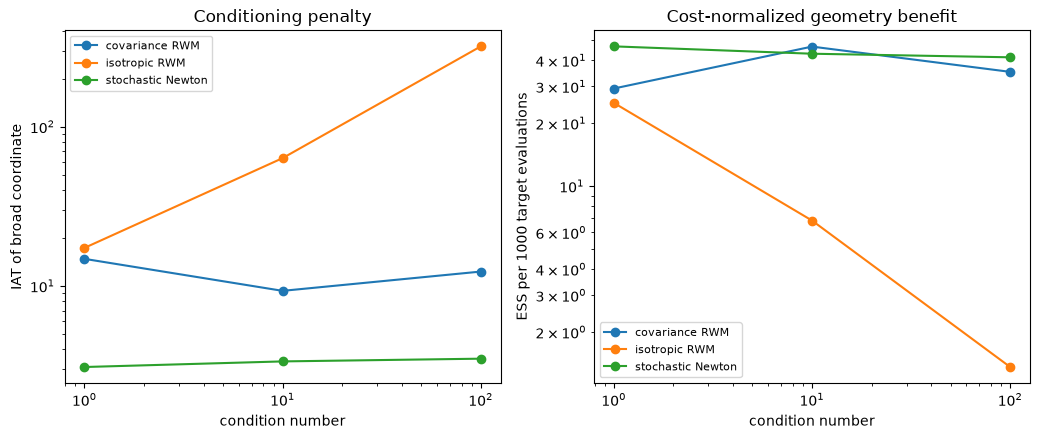

In [6]:
conditioning_rows = run_conditioning_geometry_experiment(
    condition_numbers=(1.0, 10.0, 100.0),
    n_samples=1500 if QUICK_MODE else 4500,
    burn_in=300 if QUICK_MODE else 700,
    seed=SEED,
)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for method in sorted({row.method for row in conditioning_rows}):
    selected = [row for row in conditioning_rows if row.method == method]
    axes[0].plot(
        [row.condition_number for row in selected],
        [row.empirical_iat for row in selected],
        "o-",
        label=method,
    )
    axes[1].plot(
        [row.condition_number for row in selected],
        [row.ess_per_thousand_target_evaluations for row in selected],
        "o-",
        label=method,
    )
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("condition number")
    ax.legend(fontsize=8)
axes[0].set_ylabel("IAT of broad coordinate")
axes[1].set_ylabel("ESS per 1000 target evaluations")
axes[0].set_title("Conditioning penalty")
axes[1].set_title("Cost-normalized geometry benefit")
finish_figure(fig)

## 5. Rosenbrock: local curvature versus ensemble directions

The Rosenbrock law has an exact hierarchical sampler, so means and covariance are known.
We compare local random walks, stochastic Newton, and two affine-invariant ensemble
moves. Ensemble ESS is computed from the ensemble-average time series rather than by
flattening dependent walkers and pretending they are IID.


isotropic RWM accept= 0.1184 means= (5.049, 25.633) ESS/1k eval= 0.451
fixed-covariance RWM accept= 0.1713 means= (-0.339, 6.134) ESS/1k eval= 0.598
stochastic Newton accept= 0.6865 means= (2.441, 10.671) ESS/1k eval= 0.182
stretch ensemble accept= 0.223 means= (1.135, 11.412) ESS/1k eval= 1.657
walk ensemble accept= 0.1774 means= (1.288, 10.575) ESS/1k eval= 4.778


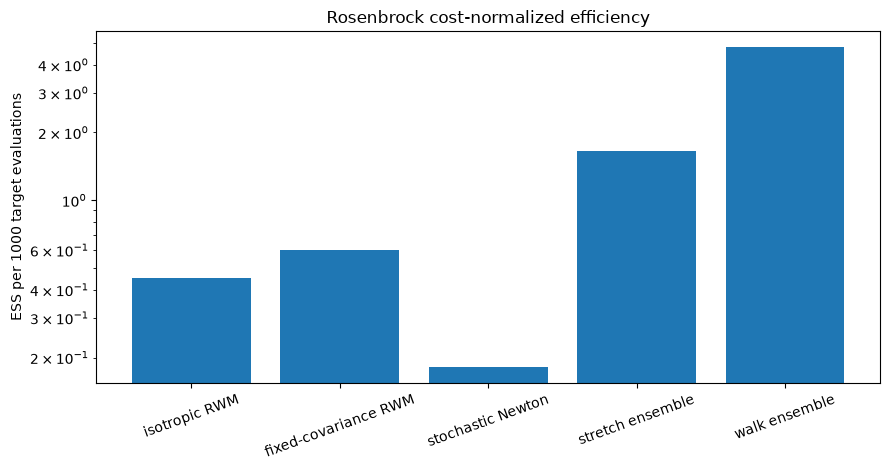

In [7]:
rosenbrock_rows = run_rosenbrock_geometry_experiment(
    n_samples=700 if QUICK_MODE else 2600,
    burn_in=180 if QUICK_MODE else 500,
    n_walkers=24,
    seed=SEED + 1,
)
for row in rosenbrock_rows:
    print(
        row.method,
        "accept=",
        round(row.acceptance_rate, 4),
        "means=",
        (round(row.mean_x, 3), round(row.mean_y, 3)),
        "ESS/1k eval=",
        round(row.ess_per_thousand_target_evaluations, 3),
    )

fig, ax = plt.subplots(figsize=(9.0, 4.8))
x_positions = np.arange(len(rosenbrock_rows))
ax.bar(
    x_positions,
    [row.ess_per_thousand_target_evaluations for row in rosenbrock_rows],
)
ax.set_xticks(x_positions, [row.method for row in rosenbrock_rows], rotation=20)
ax.set_yscale("log")
ax.set_ylabel("ESS per 1000 target evaluations")
ax.set_title("Rosenbrock cost-normalized efficiency")
finish_figure(fig)

## 6. Walker clouds and ensemble dependence

The complete ensemble is the Markov state. The next experiment starts walkers from exact
target draws, then displays their paths and computes both ensemble ESS and mean
cross-walker correlation.


In [8]:
ensemble_rngs = spawn_rngs(SEED + 40, 2)
n_walkers = 24
ensemble_steps = 450 if QUICK_MODE else 1400
ensemble_burn = 100 if QUICK_MODE else 300
ensemble_results = {}
for name, kernel, rng in (
    (
        "stretch",
        StretchMoveKernel(rosenbrock, schedule="split"),
        ensemble_rngs[0],
    ),
    (
        "walk",
        WalkMoveKernel(
            rosenbrock,
            schedule="split",
            subset_size=6,
            scale=0.2,
        ),
        ensemble_rngs[1],
    ),
):
    initial_walkers = rosenbrock.sample_exact(rng, n_walkers)
    initial_state = EnsembleState.from_target(initial_walkers, rosenbrock)
    trajectory = run_ensemble_chain(
        kernel,
        initial_state,
        rng,
        n_steps=ensemble_steps,
    )
    retained = trajectory.walkers[ensemble_burn + 1 :]
    efficiency = ensemble_effective_sample_size(retained[:, :, 0])
    cross_correlation = mean_cross_walker_correlation(retained[:, :, 0])
    ensemble_results[name] = (trajectory, efficiency, cross_correlation)
    print(
        name,
        "accept=",
        round(trajectory.acceptance_rate, 4),
        "ESS=",
        round(efficiency.effective_sample_size, 1),
        "cross-walker corr=",
        round(cross_correlation, 4),
    )

stretch accept= 0.2049 ESS= 213.4 cross-walker corr= -0.023


walk accept= 0.1816 ESS= 172.6 cross-walker corr= -0.0063


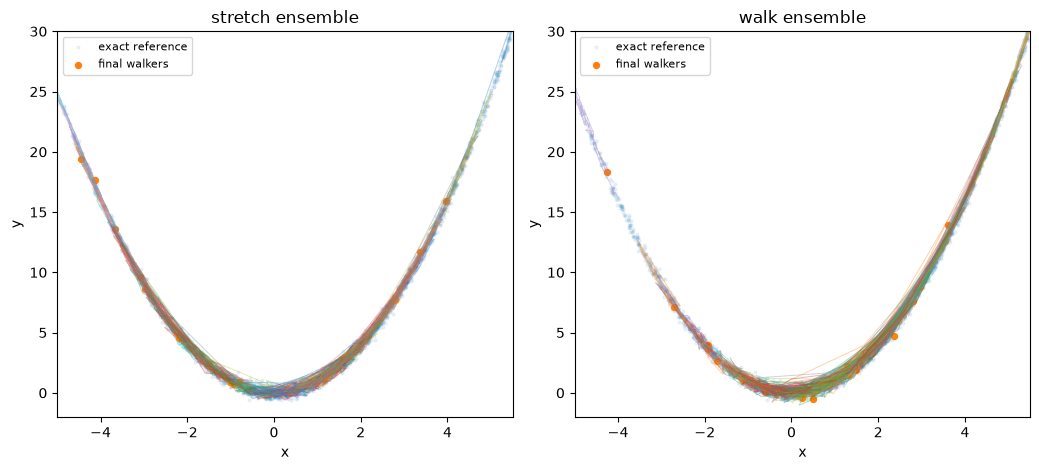

In [9]:
reference_rng = spawn_rngs(SEED + 50, 1)[0]
reference = rosenbrock.sample_exact(reference_rng, 2500)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))
for ax, name in zip(axes, ("stretch", "walk"), strict=True):
    trajectory = ensemble_results[name][0]
    ax.scatter(reference[:, 0], reference[:, 1], s=4, alpha=0.08, label="exact reference")
    for walker in range(n_walkers):
        ax.plot(
            trajectory.walkers[:: max(1, ensemble_steps // 120), walker, 0],
            trajectory.walkers[:: max(1, ensemble_steps // 120), walker, 1],
            alpha=0.35,
            linewidth=0.7,
        )
    ax.scatter(
        trajectory.walkers[-1, :, 0],
        trajectory.walkers[-1, :, 1],
        s=18,
        label="final walkers",
    )
    ax.set_xlim(-5.0, 5.5)
    ax.set_ylim(-2.0, 30.0)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{name} ensemble")
    ax.legend(fontsize=8)
finish_figure(fig)

## 7. Controlled failure: a degenerate affine span

Stretch and walk moves generate displacements from existing walker differences. If the
walkers lie in a lower-dimensional affine subspace, no sequence of those moves can create
the missing direction. The kernels therefore reject the setup explicitly.


In [10]:
degenerate_walkers = np.column_stack((np.linspace(-2.0, 2.0, 10), np.zeros(10, dtype=np.float64)))
degenerate_state = EnsembleState.from_target(degenerate_walkers, rosenbrock)
failure_message = ""
try:
    StretchMoveKernel(rosenbrock).step(
        degenerate_state,
        spawn_rngs(SEED + 60, 1)[0],
    )
except ValueError as error:
    failure_message = str(error)
print("affine-span rank:", degenerate_state.affine_span_rank)
print("explicit failure:", failure_message)

affine-span rank: 1
explicit failure: ensemble walkers do not span the target affine space


## When to use geometry or ensemble methods

- Whiten or precondition when a global covariance model is credible.
- Use stochastic Newton when local curvature is informative and Hessian cost is justified;
  report any repair rather than hiding it.
- Use ensembles when a population can reveal useful directions without fitting a global
  covariance, but initialize enough walkers to span the state dimension.
- Evaluate cost, IAT, acceptance, cross-walker dependence, and target moments together.

Further experiments: verify pathwise affine equivariance under a nonorthogonal map,
compare clipping and absolute Hessian repair on transformed Rosenbrock targets, or vary
ensemble size and split schedules.


In [11]:
by_key = {(row.condition_number, row.method): row for row in conditioning_rows}
isotropic_stiff = by_key[(100.0, "isotropic RWM")]
covariance_stiff = by_key[(100.0, "covariance RWM")]
newton_stiff = by_key[(100.0, "stochastic Newton")]
mean_errors = [
    max(abs(row.mean_x - row.exact_mean_x), abs(row.mean_y - row.exact_mean_y))
    for row in rosenbrock_rows
]
print("whitened covariance max error:", np.max(np.abs(whitened_covariance - np.eye(2))))
print("best Rosenbrock mean error:", min(mean_errors))

assert whitened_condition < 1.18
assert np.min(original_eigenvalues[:, 0]) < 0.0
assert covariance_stiff.empirical_iat < isotropic_stiff.empirical_iat
assert newton_stiff.empirical_iat < isotropic_stiff.empirical_iat
assert min(mean_errors) < (2.5 if QUICK_MODE else 1.2)
assert degenerate_state.affine_span_rank < 2
assert failure_message
assert FIGURE_COUNT >= 5
print(f"completed geometry and ensemble notebook with {FIGURE_COUNT} figures")

whitened covariance max error: 0.02017696062937613
best Rosenbrock mean error: 0.4115359544227317
completed geometry and ensemble notebook with 5 figures
